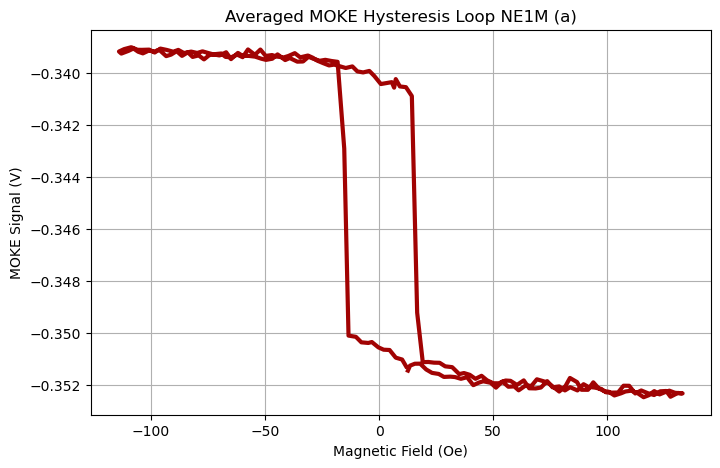

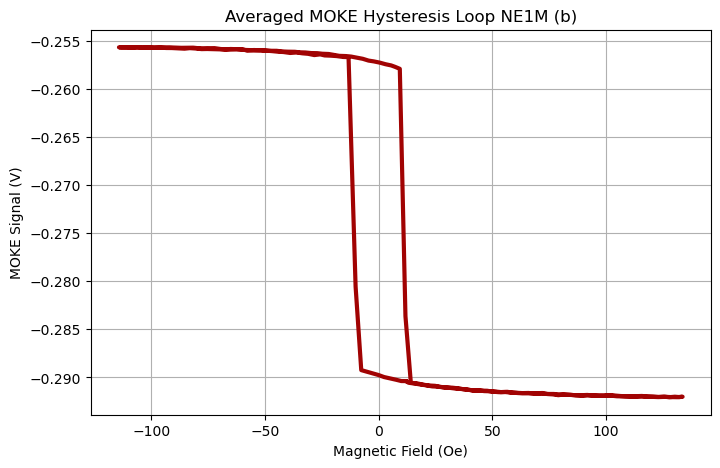

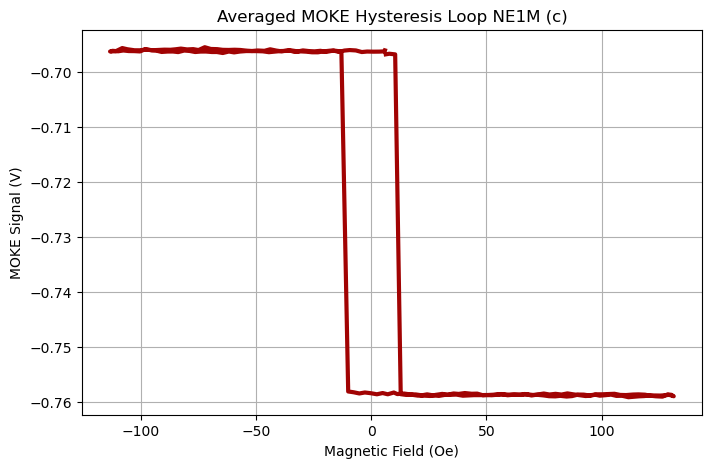

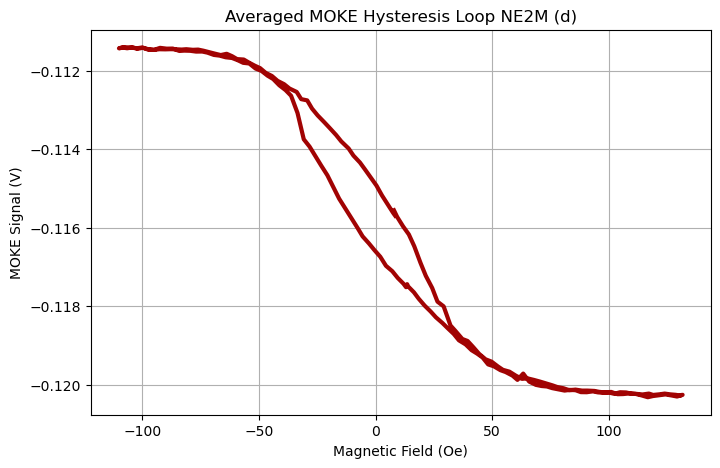

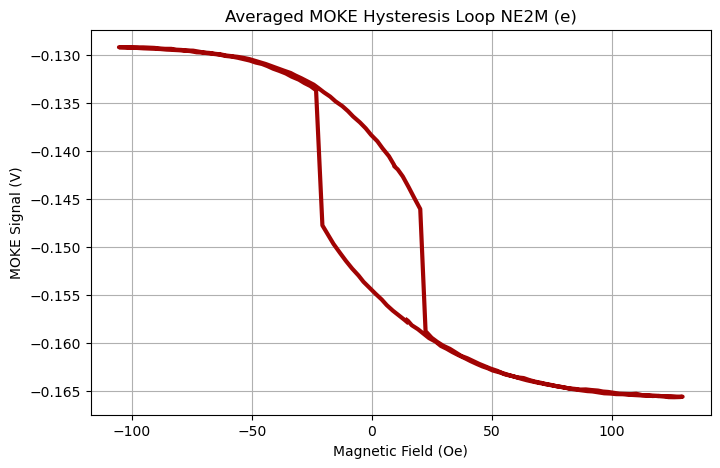

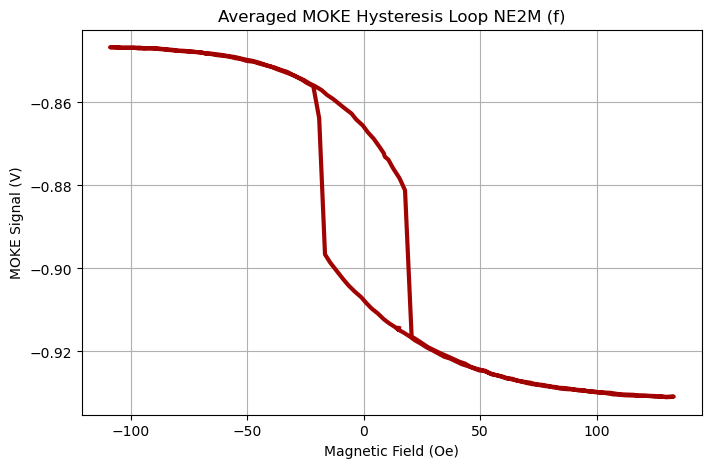

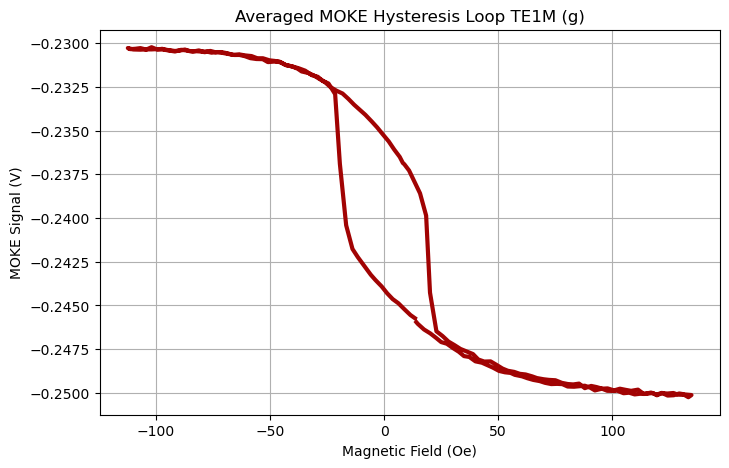

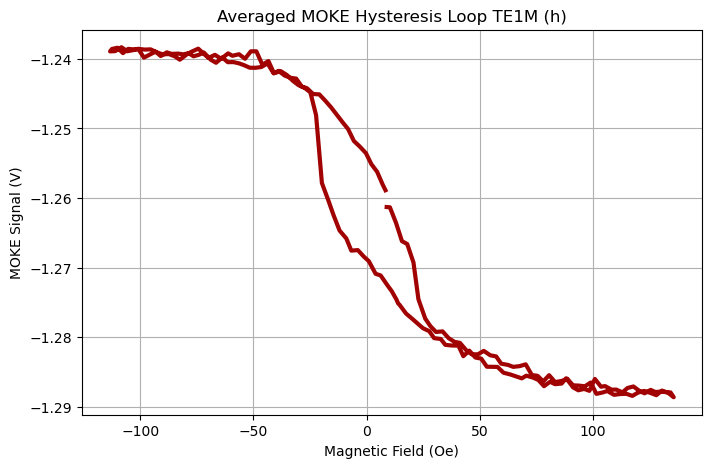

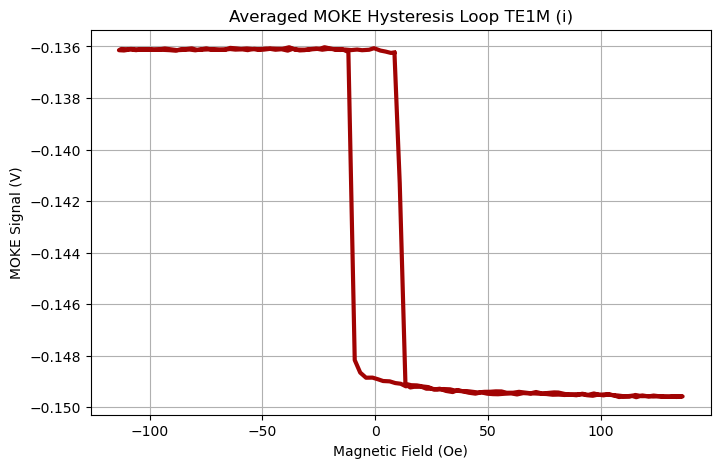

In [10]:
'''
author: amir kamalian
date: 21 may 2026

Hysteresis loops singal
'''


import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

# headers: time(ms),field(Oe),signal(V),angle,step
a = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G5.csv')
b = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G1.csv')
c = pd.read_csv('../../MOKE-raw-data/2026_MAY_20-GdCo_Lily_NE1M_G3.csv')
d = pd.read_csv('../../MOKE-raw-data/2026_MAY_14-GdCo_Lily_NE2M_G2.csv')
e = pd.read_csv('../../MOKE-raw-data/2026_MAY_13-GdCo_Lily_NE2M_G1.csv')
f = pd.read_csv('../../MOKE-raw-data/2026_MAY_14-GdCo_Lily_NE2M_G3.csv')
g = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G4.csv')
h = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G1.csv')
i = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G2.csv')


df = [a, b, c, d, e, f, g, h, i]
titles = ["NE1M", "NE1M", "NE1M", "NE2M", "NE2M", "NE2M", "TE1M", "TE1M", "TE1M"]
position = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)"]
n = 0

''' 
we must take the average of each of the polarities
'''
for G in df:
    # separating the cycles by steps 
    G["cycle"] = (G["step"].diff() < 0).cumsum()
    
    # separating polarities 
    even_polarity = G[G["cycle"] % 2 == 0]
    odd_polarity = G[G["cycle"] % 2 == 1]
    
    # averaging the respective polarities 
    evenp_avg = even_polarity.groupby("step").aggregate({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })
    
    oddp_avg = odd_polarity.groupby("step").aggregate({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })
    
    
    # combining results
    df_final = pd.concat([evenp_avg, oddp_avg], axis=0)
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    
    # ax1: applied field vs signal 
    ax.plot(df_final["field(Oe)"], df_final["signal(V)"], color="#a10303", linewidth=3)
    
    ax.set_xlabel("Magnetic Field (Oe)")
    ax.set_ylabel("MOKE Signal (V)")
    ax.set_title("Averaged MOKE Hysteresis Loop " + titles[n] + " " + position[n])
    ax.grid()
    
    # ax2: applied field vs kerr angle 
    # ax2.plot(df_final["field(Oe)"], -df_final["angle"], color="#6707a3")
    
    # ax2.set_xlabel("Magnetic Field (Oe)")
    # ax2.set_ylabel("Kerr angle")
    # ax2.set_title("Kerr angle hysteresis loop N2EM")
    # ax2.grid()
    # plt.savefig("./GdCo_Lily_NE2M-hysteresis_loops/2026_MAY_21-GdCo_LL3S_" + titles[n] + "_" + position[n])

    n+=1

plt.show()




<h1>First Series of MOKE Scans</h1>
<p>
    The first series of MOKE scans on cuts NE1M, NE2M, and TE1M of sample LL3S. Positions of scans are shown in Figure 1 below. The position of each scan site was measured from the edges of the respective cut of the scan site (in cm). 
</p>

<figure>
  <img src="./Slide2.jpg" alt="Alt text" style="width:50%">
  <figcaption align="center">Figure 1: First series scan sites (a)-(i) for cuts NE1M, NE2M, and TE1M cuts of LL3S.</figcaption>
</figure>


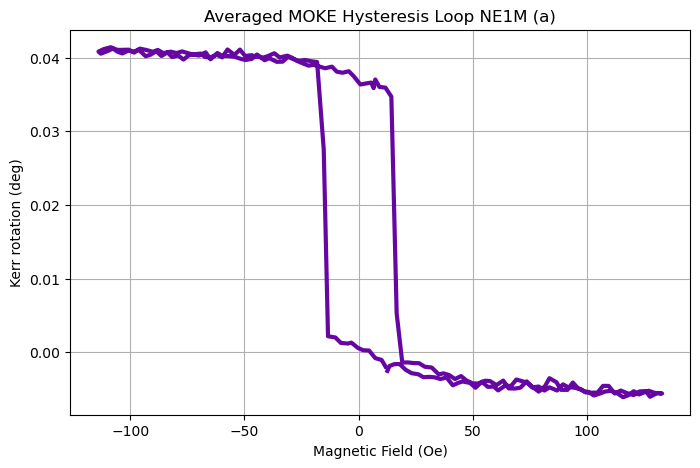

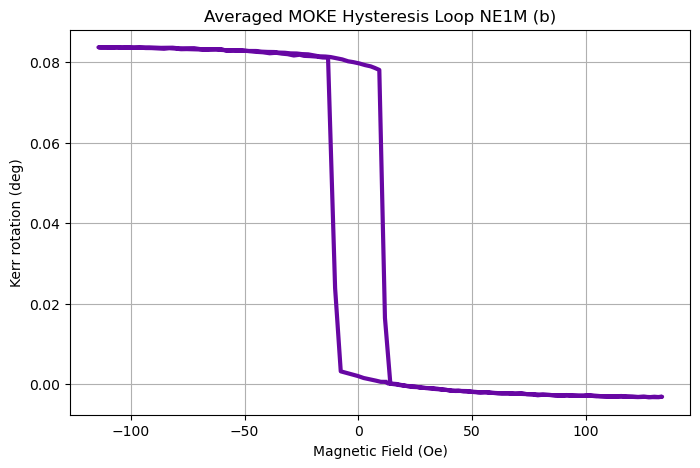

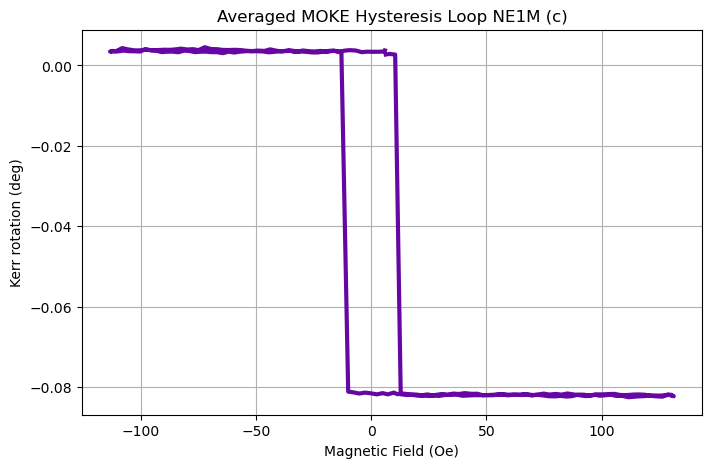

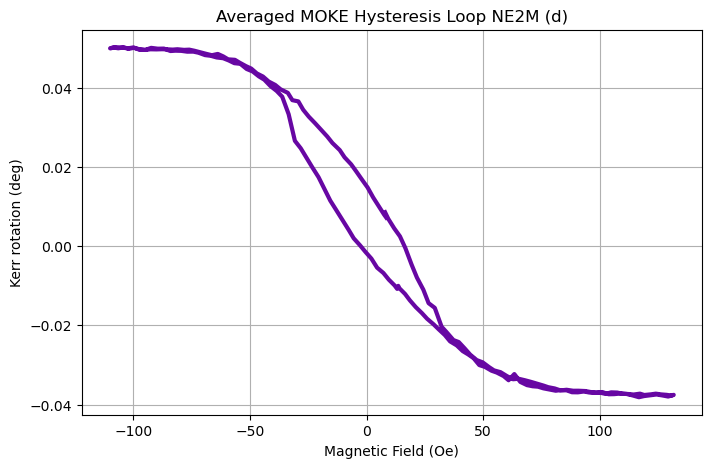

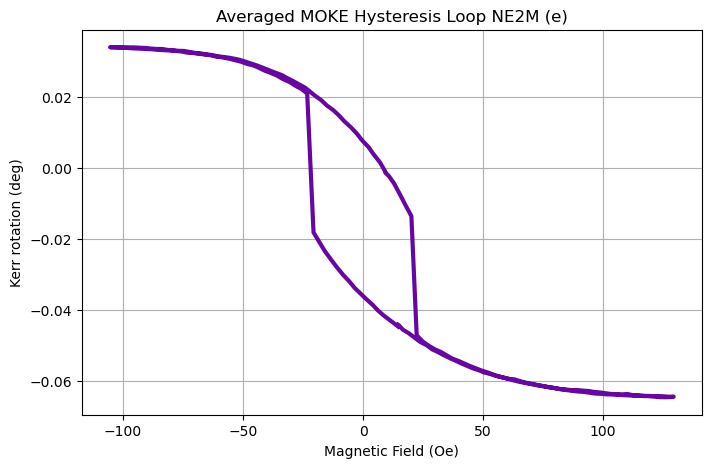

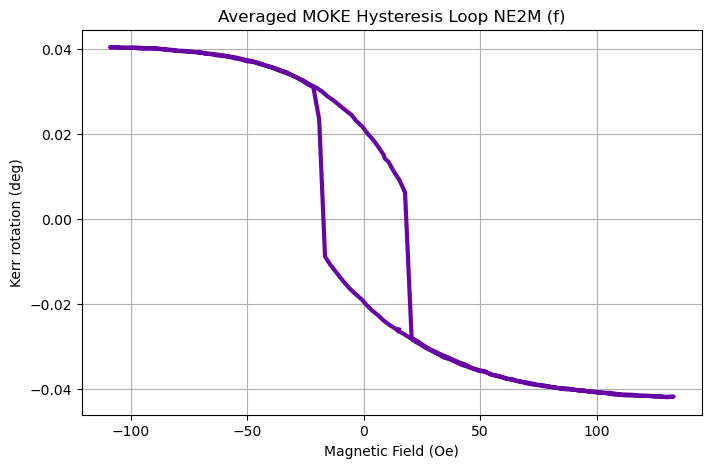

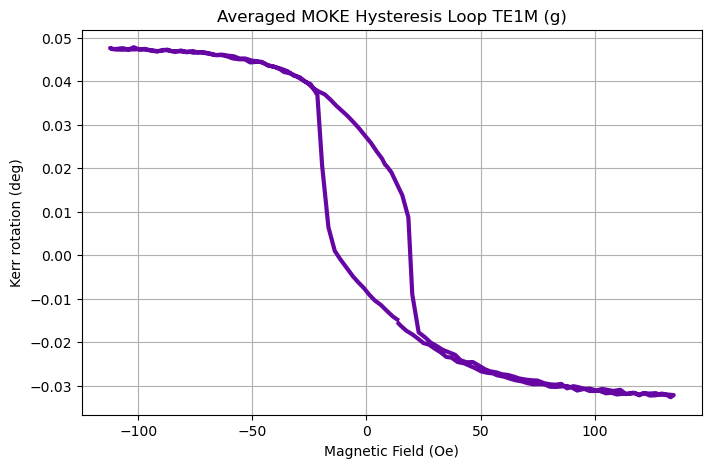

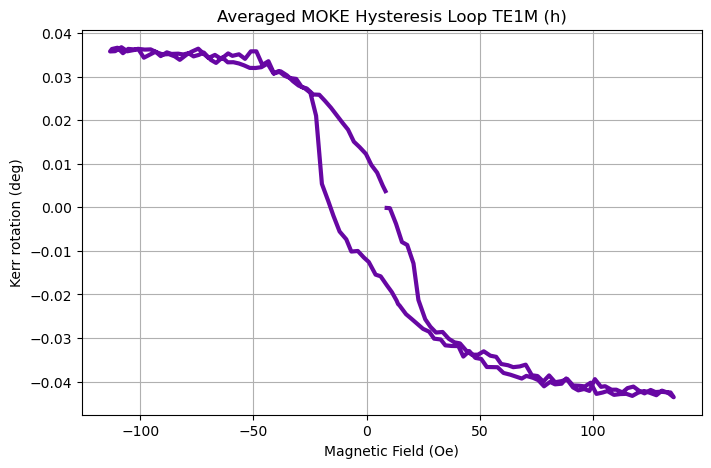

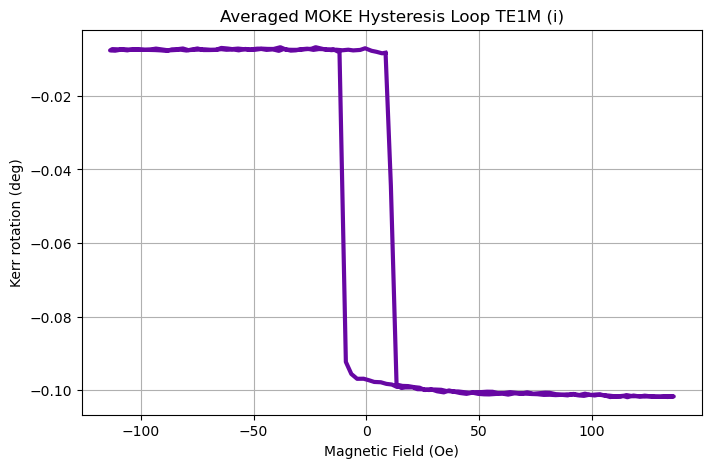

In [11]:
'''
Hysteresis loops Kerr rotation 
'''

import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

# headers: time(ms),field(Oe),signal(V),angle,step
a = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G5.csv')
b = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G1.csv')
c = pd.read_csv('../../MOKE-raw-data/2026_MAY_20-GdCo_Lily_NE1M_G3.csv')
d = pd.read_csv('../../MOKE-raw-data/2026_MAY_14-GdCo_Lily_NE2M_G2.csv')
e = pd.read_csv('../../MOKE-raw-data/2026_MAY_13-GdCo_Lily_NE2M_G1.csv')
f = pd.read_csv('../../MOKE-raw-data/2026_MAY_14-GdCo_Lily_NE2M_G3.csv')
g = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G4.csv')
h = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G1.csv')
i = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G2.csv')


df = [a, b, c, d, e, f, g, h, i]
titles = ["NE1M", "NE1M", "NE1M", "NE2M", "NE2M", "NE2M", "TE1M", "TE1M", "TE1M"]
position = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)"]
n = 0

''' 
we must take the average of each of the polarities
'''
for G in df:
    # separating the cycles by steps 
    G["cycle"] = (G["step"].diff() < 0).cumsum()
    
    # separating polarities 
    even_polarity = G[G["cycle"] % 2 == 0]
    odd_polarity = G[G["cycle"] % 2 == 1]
    
    # averaging the respective polarities 
    evenp_avg = even_polarity.groupby("step").aggregate({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })
    
    oddp_avg = odd_polarity.groupby("step").aggregate({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })
    
    
    # combining results
    df_final = pd.concat([evenp_avg, oddp_avg], axis=0)
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    
    # ax1: applied field vs signal 
    ax.plot(df_final["field(Oe)"], -df_final["angle"], color="#6707a3", linewidth=3)
    
    ax.set_xlabel("Magnetic Field (Oe)")
    ax.set_ylabel("Kerr rotation (deg)")
    ax.set_title("Averaged MOKE Hysteresis Loop " + titles[n] + " " + position[n])
    ax.grid()
    
    # ax2: applied field vs kerr angle 
    # ax2.plot(df_final["field(Oe)"], -df_final["angle"], color="#6707a3")
    
    # ax2.set_xlabel("Magnetic Field (Oe)")
    # ax2.set_ylabel("Kerr angle")
    # ax2.set_title("Kerr angle hysteresis loop N2EM")
    # ax2.grid()
    # plt.savefig("./GdCo_Lily_NE2M-hysteresis_loops/2026_MAY_21-GdCo_LL3S_kerrRotation_" + titles[n] + "_" + position[n])

    n+=1

plt.show()




0.013467833333333346
0.03637640000000003
0.06185980000000002
0.001960181818181833
0.03641709999999998
0.08431840909090915
0.02001880555555552
0.013326249999999984
0.012922749999999983
  sample  amplitude
0    (a)   0.013468
1    (b)   0.036376
2    (c)   0.061860
3    (d)   0.001960
4    (e)   0.036417
5    (f)   0.084318
6    (g)   0.020019
7    (h)   0.013326
8    (i)   0.012923


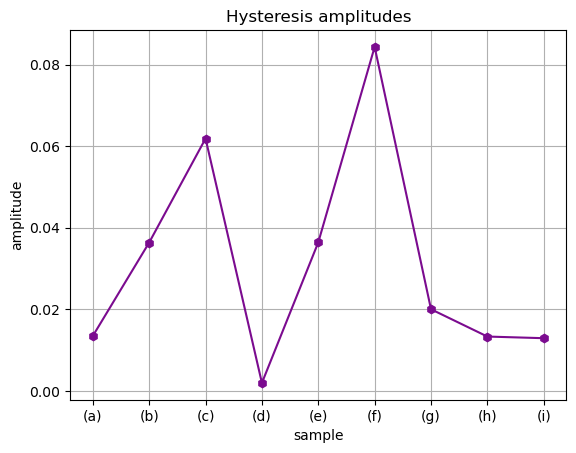

In [38]:
'''
compensation composition 
'''

import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 


# headers: time(ms),field(Oe),signal(V),angle,step
a = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G5.csv')
b = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G1.csv')
c = pd.read_csv('../../MOKE-raw-data/2026_MAY_20-GdCo_Lily_NE1M_G3.csv')
d = pd.read_csv('../../MOKE-raw-data/2026_MAY_14-GdCo_Lily_NE2M_G2.csv')
e = pd.read_csv('../../MOKE-raw-data/2026_MAY_13-GdCo_Lily_NE2M_G1.csv')
f = pd.read_csv('../../MOKE-raw-data/2026_MAY_14-GdCo_Lily_NE2M_G3.csv')
g = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G4.csv')
h = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G1.csv')
i = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G2.csv')

# combined dataframe
df = [a, b, c, d, e, f, g, h, i]
n = 0


def average_out(dataframe: pd.DataFrame): 
    # separating the cycles by steps 
    dataframe["cycle"] = (dataframe["step"].diff() < 0).cumsum()
    
    # separating polarities 
    even_polarity = dataframe[dataframe["cycle"] % 2 == 0]
    odd_polarity = dataframe[dataframe["cycle"] % 2 == 1]
    
    # averaging the respective polarities 
    evenp_avg = even_polarity.groupby("step").aggregate({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })
    
    oddp_avg = odd_polarity.groupby("step").aggregate({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })

    # combining results
    amplitude = (evenp_avg["signal(V)"].max() - oddp_avg["signal(V)"].min()) 
    print(amplitude)

    return amplitude


# hysteresis amplitudes 
amplitudes = []
for d in df:
    amplitudes.append(average_out(d))

# convert to dataframe 
amp_df = pd.DataFrame({
    "sample": ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)"],
    "amplitude": amplitudes
})

print(amp_df)

plt.plot(amp_df["sample"], amp_df["amplitude"], color="#7b0b8f", marker="h")
plt.grid()
plt.xlabel("sample")
plt.ylabel("amplitude")
plt.title("Hysteresis amplitudes")
plt.savefig("./2026_MAY_21-GdCo_LL3S_hysteresis_amplitudes")

plt.show()


Reference amplitude = 0.047541
(a) Amplitude = 0.047541  Relative = 1.0
(b) Amplitude = 0.08703919999999998  Relative = 1.8308239204055443
(c) Amplitude = 0.0870808  Relative = 1.8316989545865674
(d) Amplitude = 0.0883069090909091  Relative = 1.857489516226186
(e) Amplitude = 0.0986046  Relative = 2.0740960434151576
(f) Amplitude = 0.08245178181818182  Relative = 1.7343299850272778
(g) Amplitude = 0.0804148888888889  Relative = 1.6914850105990387
(h) Amplitude = 0.080355875  Relative = 1.6902436843987294
(i) Amplitude = 0.09505487500000001  Relative = 1.9994294398519175


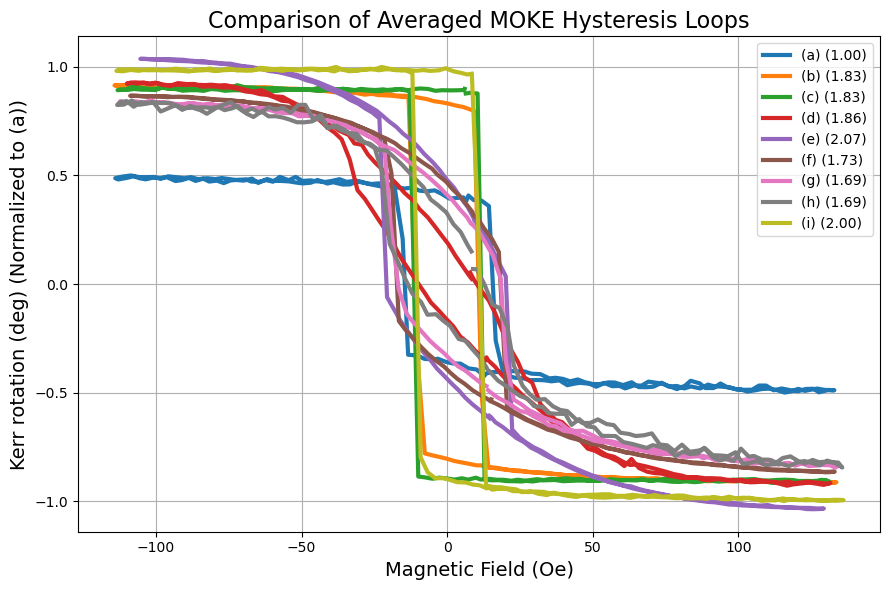

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# headers:
# time(ms),field(Oe),signal(V),angle,step
a = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G5.csv')
b = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G1.csv')
c = pd.read_csv('../../MOKE-raw-data/2026_MAY_20-GdCo_Lily_NE1M_G3.csv')

d = pd.read_csv('../../MOKE-raw-data/2026_MAY_14-GdCo_Lily_NE2M_G2.csv')
e = pd.read_csv('../../MOKE-raw-data/2026_MAY_13-GdCo_Lily_NE2M_G1.csv')
f = pd.read_csv('../../MOKE-raw-data/2026_MAY_14-GdCo_Lily_NE2M_G3.csv')

g = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G4.csv')
h = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G1.csv')
i = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G2.csv')


dfs = [a, b, c, d, e, f, g, h, i]
titles = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)"]


# FUNCTION: AVERAGE HYSTERESIS LOOP
def process_loop(G):

    # Detect cycles
    G = G.copy()

    G["cycle"] = (G["step"].diff() < 0).cumsum()

    # Separate sweep directions
    even_polarity = G[G["cycle"] % 2 == 0]
    odd_polarity  = G[G["cycle"] % 2 == 1]

    # Average each polarity
    even_avg = even_polarity.groupby("step").agg({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean" 
    })

    odd_avg = odd_polarity.groupby("step").agg({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })

    # Combine branches
    field = pd.concat([
        even_avg["field(Oe)"],
        odd_avg["field(Oe)"]
    ])

    signal = pd.concat([
        even_avg["signal(V)"],
        odd_avg["signal(V)"]
    ])

    angle = pd.concat([
        even_avg["angle"],
        odd_avg["angle"]
    ])

    # Remove vertical offset
    offset = (angle.max() + angle.min()) / 2

    angle_centered = angle - offset

    # Compute amplitude
    amplitude = (angle_centered.max() - angle_centered.min())

    return field, angle_centered, amplitude

# =========================================================
# REFERENCE NORMALIZATION
# =========================================================

# Use first dataset as reference
ref_field, ref_angle, reference_amplitude = process_loop(a)

print("Reference amplitude =", reference_amplitude)

# =========================================================
# PLOT ALL LOOPS TOGETHER
# =========================================================

fig, ax = plt.subplots(figsize=(9,6))

for n, G in enumerate(dfs):

    # Process loop
    field, angle_centered, amplitude = process_loop(G)

    # Normalize to REFERENCE amplitude
    angle_scaled = angle_centered / reference_amplitude
    
    # Print amplitudes
    relative_amplitude = amplitude / reference_amplitude

    print(titles[n], "Amplitude =", amplitude, " Relative =", relative_amplitude)

    # Plot
    ax.plot(field, -angle_scaled, linewidth=3, label=f"{titles[n]} ({relative_amplitude:.2f})")

# =========================================================
# FORMAT PLOT
# =========================================================

ax.set_xlabel("Magnetic Field (Oe)", fontsize=14)
ax.set_ylabel("Kerr rotation (deg) (Normalized to (a))", fontsize=14)
ax.set_title("Comparison of Averaged MOKE Hysteresis Loops", fontsize=16)
ax.grid(True)
ax.legend()

plt.tight_layout()
# plt.savefig("./GdCo_Lily_NE2M-hysteresis_loops/2026_MAY_21-GdCo_LL3S_kerrRotation_normalized")

plt.show()

<h1>Normalized averaged hysteresis</h1>

<p>
To centre the averaged Kerr rotation loops, the averaged offset was subtracted from each point in the dataset. The first dataset was then used as a reference to normalize against using its hysteresis amplitude. 
</p>

$$A_{\text{ref}} = M_{\text{max}}^{\text{(ref)}} - M_{\text{max}}^{\text{(ref)}} $$

$$M_{\text{scaled}} = \dfrac{M - M_{\text{offset}}}{A_{\text{ref}}} $$



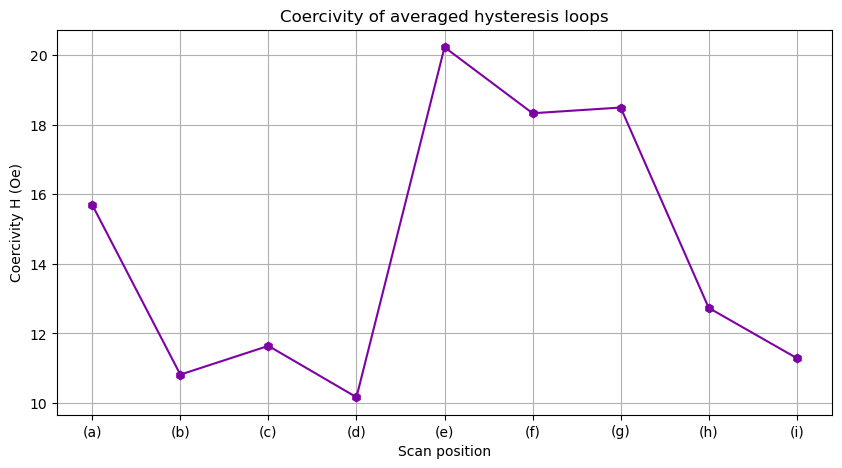

In [76]:
'''
author: amir kamalian
date: 22 may 2026

coercivity vs composition 
'''

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# headers:
# time(ms),field(Oe),signal(V),angle,step
a = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G5.csv')
b = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G1.csv')
c = pd.read_csv('../../MOKE-raw-data/2026_MAY_20-GdCo_Lily_NE1M_G3.csv')

d = pd.read_csv('../../MOKE-raw-data/2026_MAY_14-GdCo_Lily_NE2M_G2.csv')
e = pd.read_csv('../../MOKE-raw-data/2026_MAY_13-GdCo_Lily_NE2M_G1.csv')
f = pd.read_csv('../../MOKE-raw-data/2026_MAY_14-GdCo_Lily_NE2M_G3.csv')

g = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G4.csv')
h = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G1.csv')
i = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_TE1M_G2.csv')


dfs = [a, b, c, d, e, f, g, h, i]
titles = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)"]

# ---------------------------------------------------------------------------------
# FUNCTION: AVERAGE HYSTERESIS LOOP
def process_loop(G):

    # Detect cycles
    G = G.copy()

    G["cycle"] = (G["step"].diff() < 0).cumsum()

    # Separate sweep directions
    even_polarity = G[G["cycle"] % 2 == 0]
    odd_polarity  = G[G["cycle"] % 2 == 1]

    # Average each polarity
    even_avg = even_polarity.groupby("step").agg({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean" 
    })

    odd_avg = odd_polarity.groupby("step").agg({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })

    # Combine branches
    field = pd.concat([
        even_avg["field(Oe)"],
        odd_avg["field(Oe)"]
    ])

    signal = pd.concat([
        even_avg["signal(V)"],
        odd_avg["signal(V)"]
    ])

    angle = pd.concat([
        even_avg["angle"],
        odd_avg["angle"]
    ])

    # Remove vertical offsets
    angle_offset = (angle.max() + angle.min()) / 2
    signal_offset = (signal.max() + signal.min()) / 2

    angle_centered = angle - angle_offset
    signal_centered = signal - signal_offset

    df_final = pd.concat([field, signal_centered, angle_centered], axis=1)

    return df_final
    

# FUNCTION: determning the zero crossings (for coercivity plot)
def zero_crossing(df: pd.DataFrame, ylabel: str):

    field = np.array(df['field(Oe)'])
    ylabel = np.array(df[ylabel])
    
    zero_crossings = []
    for i in range(len(ylabel) - 1):
        y1 = ylabel[i]
        y2 = ylabel[i + 1]

        # zero crossing has been detected
        if y1*y2 < 0:
            H1 = field[i]
            H2 = field[i + 1]

            # Linear interpolation
            Hc = H1 - y1 * (H2 - H1) / (y2 - y1)

            zero_crossings.append(Hc)

    return zero_crossings
# ---------------------------------------------------------------------------------


# plotting coercivity versus scanned positions 
p_coercivity = []
n_coercivity = []
n=0
for n, G in enumerate(dfs):
    
    data = process_loop(G) 
    zeros = zero_crossing(data, 'angle')

    if zeros[0] > 0:
        p_coercivity.append(zeros[0])
    elif zeros[0] < 0:
        n_coercivity.append(zeros[0])
    
    if zeros[1] > 0:
        p_coercivity.append(zeros[1])
    elif zeros[1] < 0:
        n_coercivity.append(zeros[1])


# converting to dataframe
coerc_df = pd.DataFrame({
    "sample" : ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)"],
    "coercivity(Oe)" : p_coercivity
})

# plotting positive coercivity values only 
plt.figure(figsize=(10,5))
plt.plot(coerc_df['sample'], coerc_df['coercivity(Oe)'], color="#7e02a3", marker="h")
plt.title("Coercivity of averaged hysteresis loops")
plt.ylabel("Coercivity H (Oe)")
plt.xlabel("Scan position")
plt.grid()

plt.savefig("./2026_MAY_22-GdCo_LL3S_coercivity")

plt.show()
    





<h1>Second Series of Scan Sites</h1>

<p>
    The second series of scan sites 
</p>

<figure>
  <img src="./Slide2.jpg" alt="Alt text" style="width:50%">
  <figcaption align="center">Figure 2: The second series scan sites (j)-(s).</figcaption>
</figure>




---
<h1>Raw Data plots</h1>

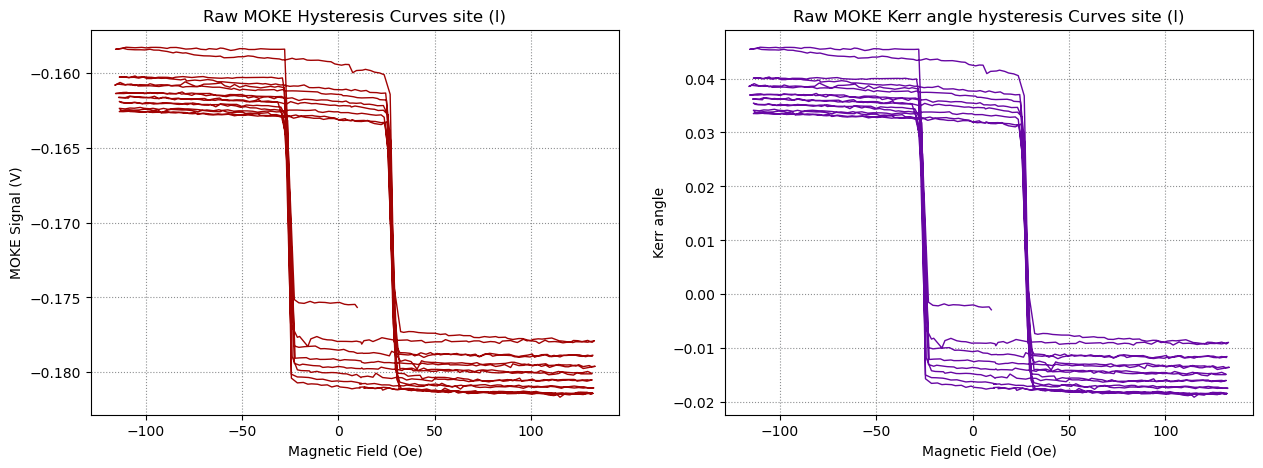

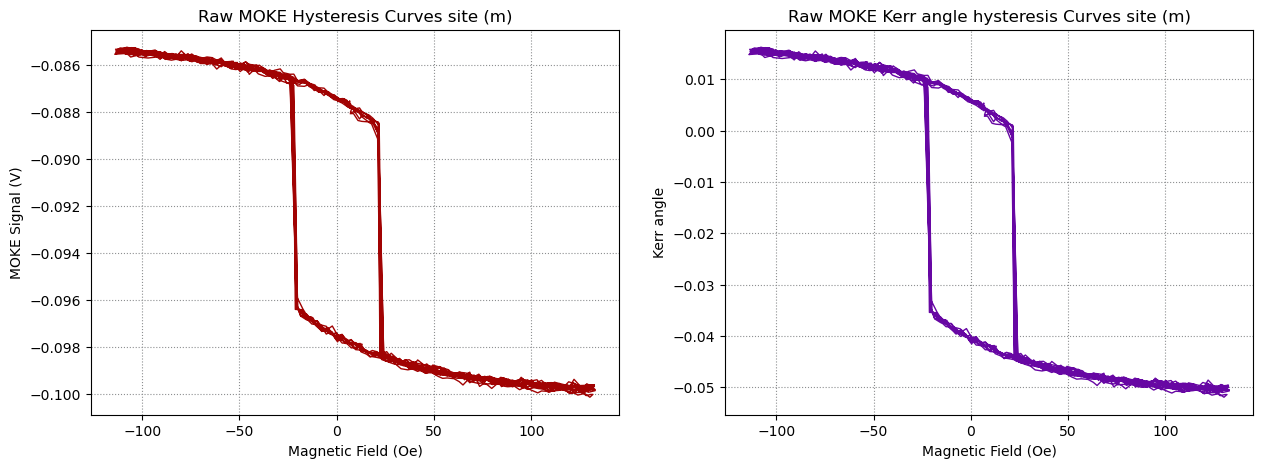

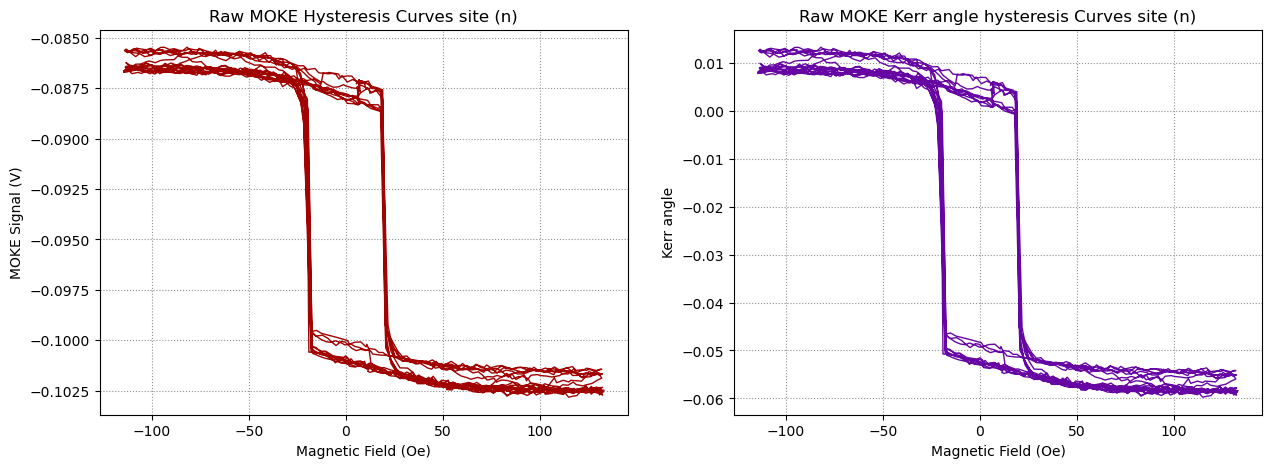

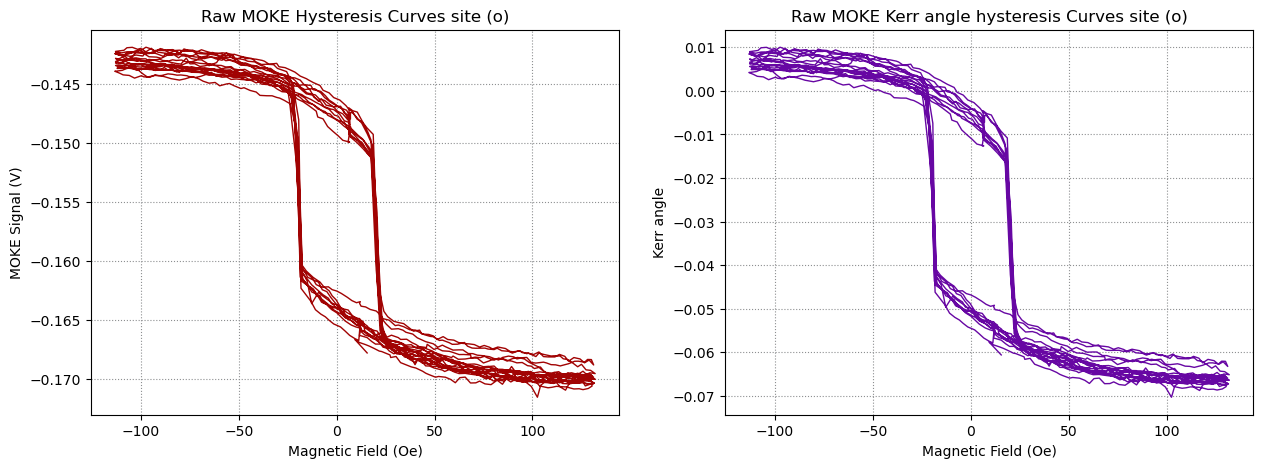

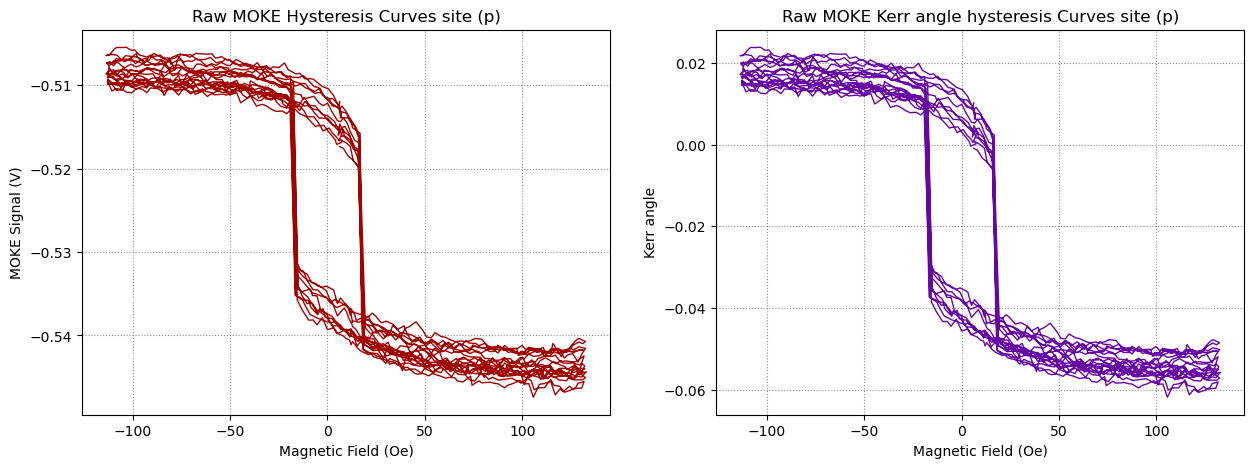

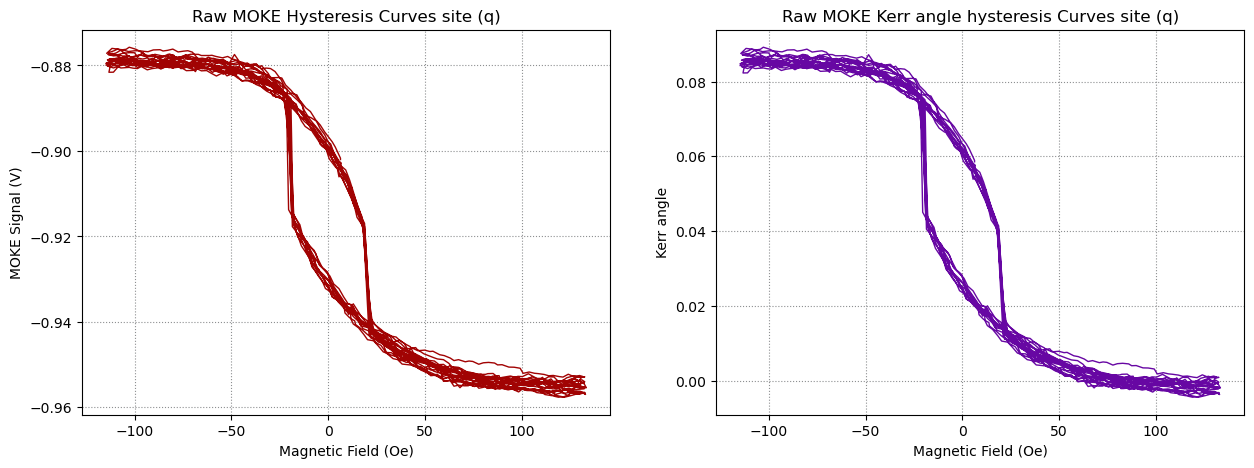

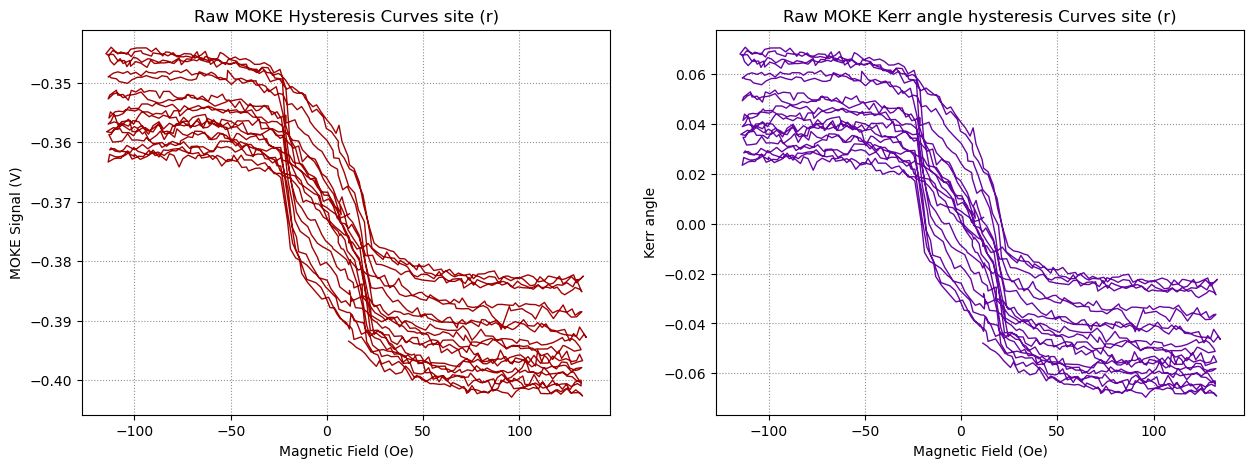

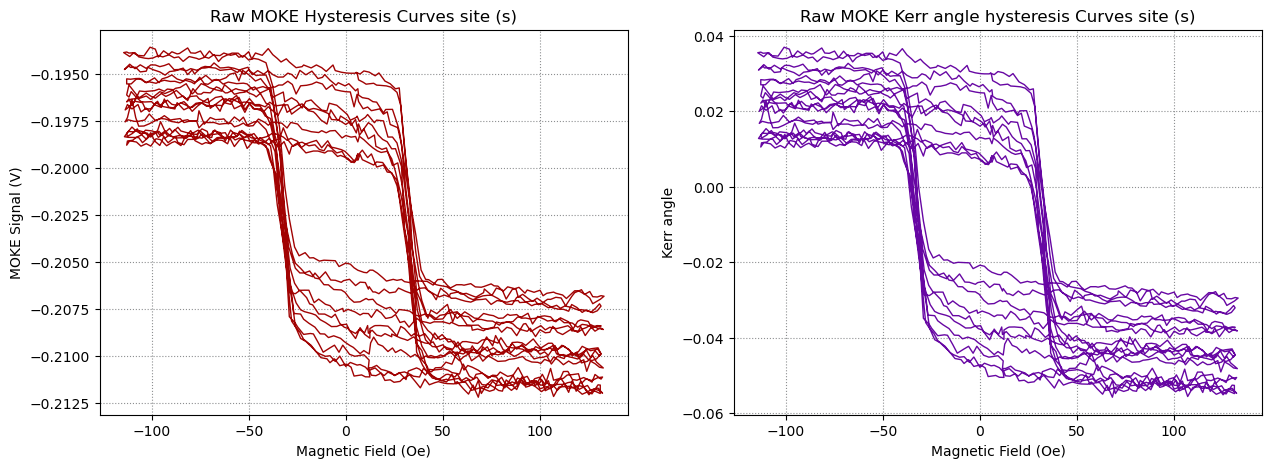

In [98]:
'''
author: amir kamalian
date: 28 may 2026

second series of MOKE scans
'''

import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

# headers: time(ms),field(Oe),signal(V),angle,step
# j = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G5.csv') --> did not scan
# k = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G1.csv') --> did not scan

l = pd.read_csv('../../MOKE-raw-data/2026_MAY_27-GdCo_Lily_LELM_P8.csv')
m = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P7.csv')
n = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P6.csv')
o = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P5.csv')
p = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_R1LM_P4.csv')
q = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_R1LM_P3.csv')
r = pd.read_csv('../../MOKE-raw-data/2026_MAY_25-GdCo_Lily_R1LM_P2.csv')
s = pd.read_csv('../../MOKE-raw-data/2026_MAY_25-GdCo_Lily_LERC_P1.csv')

df = [l, m, n, o, p, q, r, s]
titles = ["(l)", "(m)", "(n)", "(o)", "(p)", "(q)", "(r)", "(s)"]
n = 0

''' 
Plotting the hysteresis curves without averaging
'''
for G in df:    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios" : [1,1]})
    
    # ax1: applied field vs signal 
    ax1.plot(G["field(Oe)"], G["signal(V)"], color="#a10303", linewidth=1)
    
    ax1.set_xlabel("Magnetic Field (Oe)")
    ax1.set_ylabel("MOKE Signal (V)")
    ax1.set_title("Raw MOKE Hysteresis Curves site " + titles[n])
    ax1.grid(which="minor", color="#8d8f91", linestyle=":")
    ax1.grid(which="major", color="#8d8f91", linestyle=":")
    
    # ax2: applied field vs kerr angle 
    ax2.plot(G["field(Oe)"], -G["angle"], color="#6707a3", linewidth=1)
    
    ax2.set_xlabel("Magnetic Field (Oe)")
    ax2.set_ylabel("Kerr angle")
    ax2.set_title("Raw MOKE Kerr angle hysteresis Curves site " + titles[n])
    ax2.grid(which="minor", color="#8d8f91", linestyle=":")
    ax2.grid(which="major", color="#8d8f91", linestyle=":")
    # plt.savefig("./GdCo_Lily_second_series_plots/2026_MAY_28-GdCo_LL3S_scan_site_rawPlots_signal_and_kerrRotation_" + titles[n])

    n+=1

plt.show()






---
<h1>Averaged Hysteresis Cruves</h1>

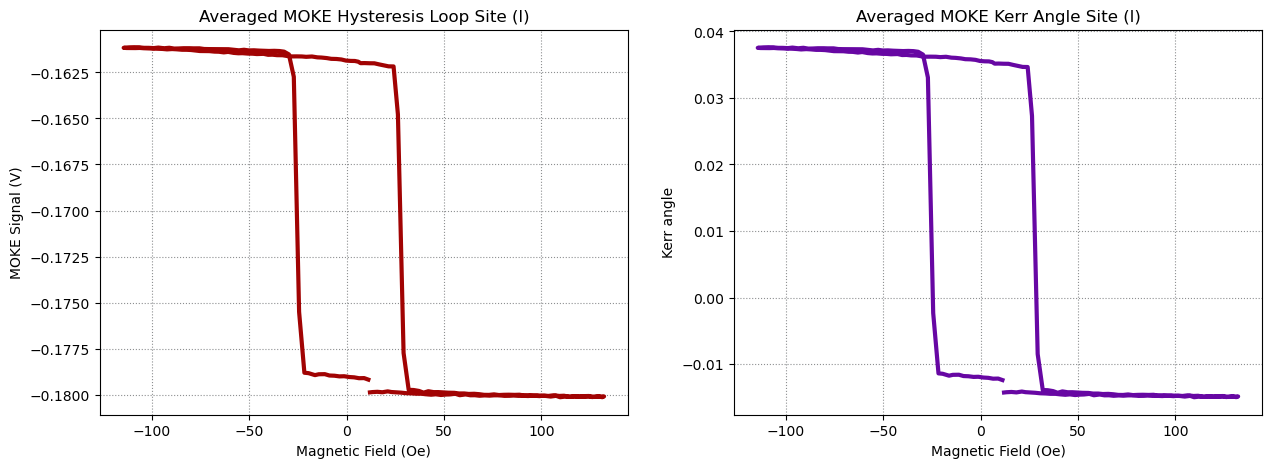

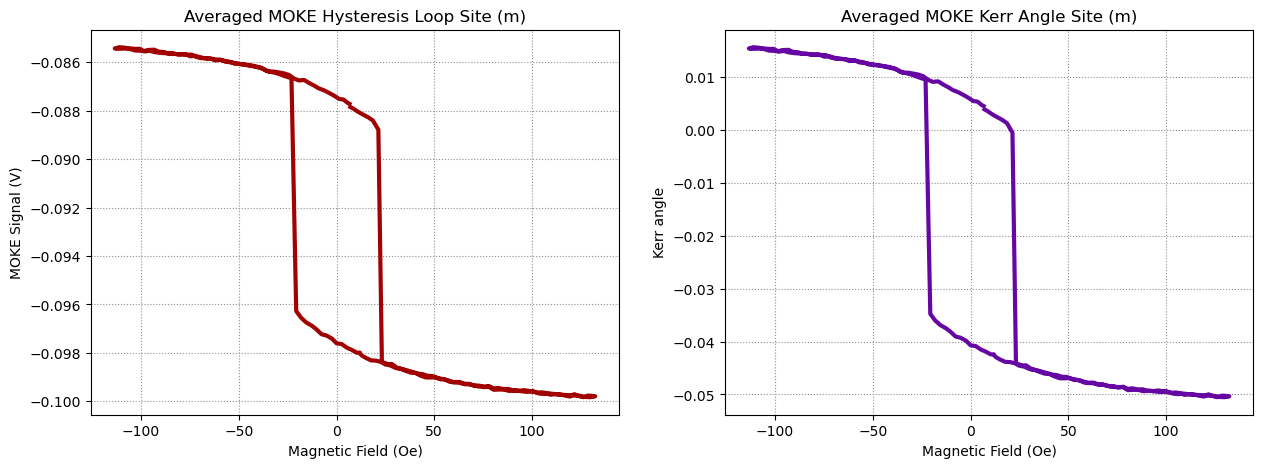

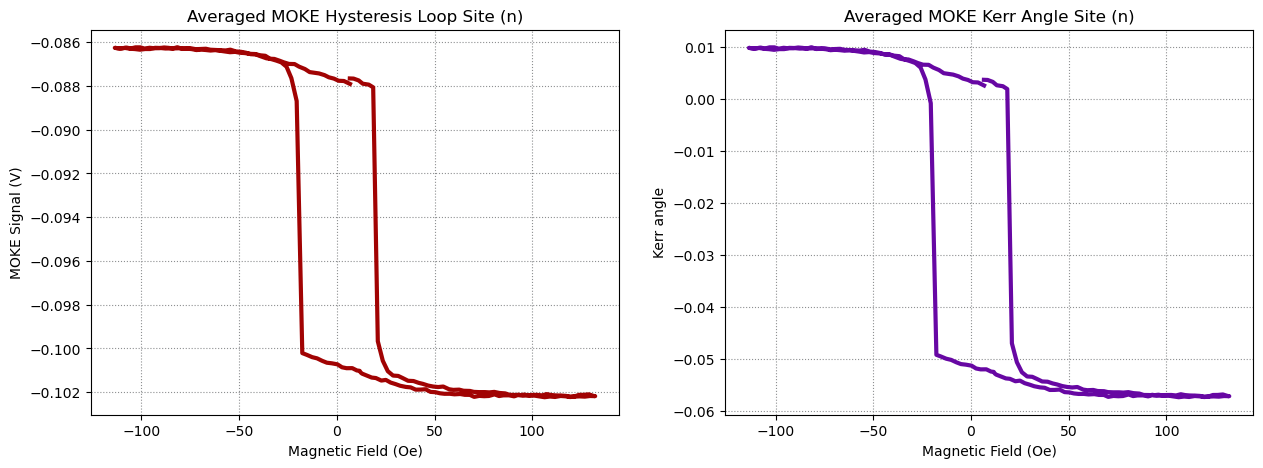

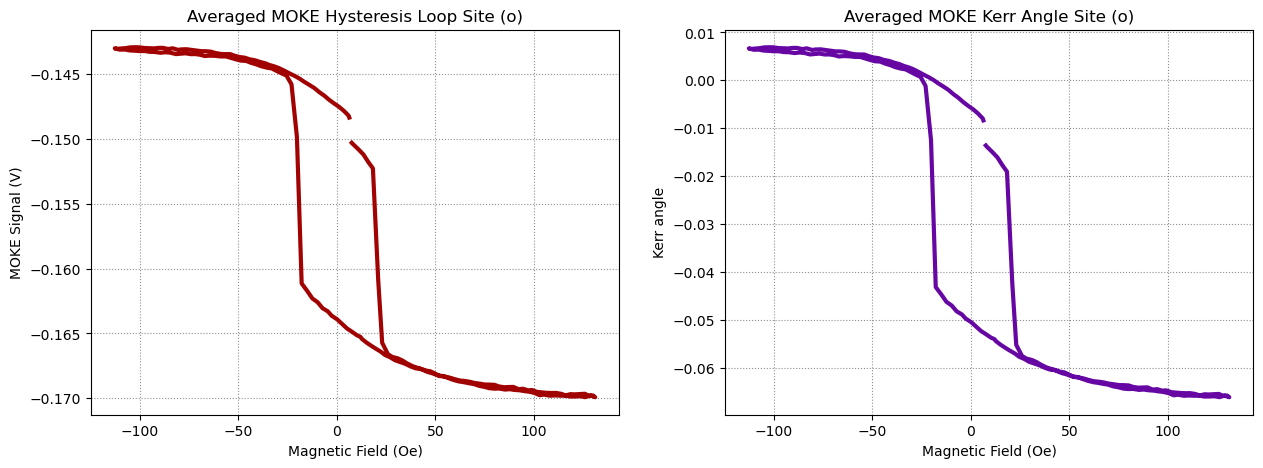

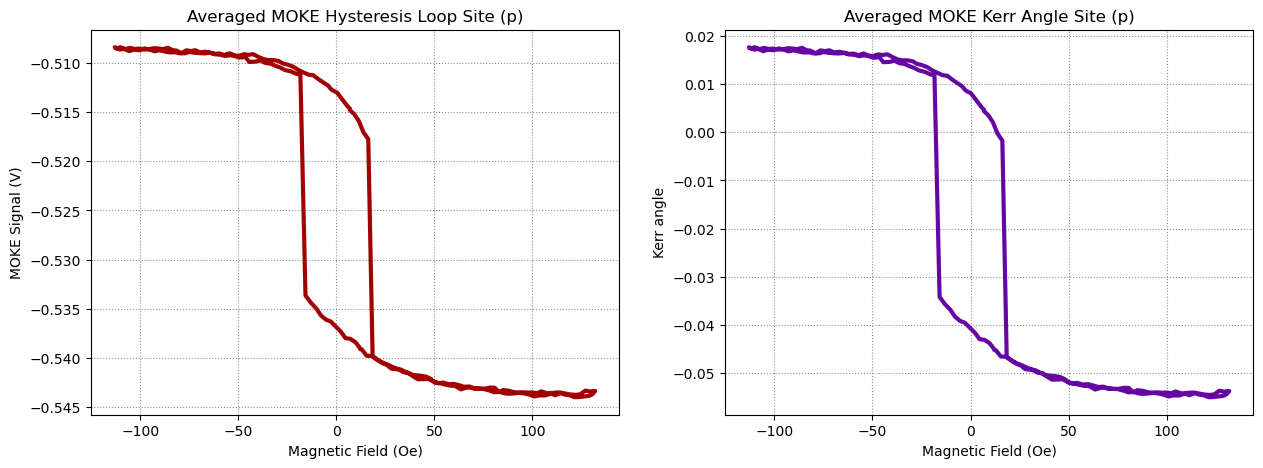

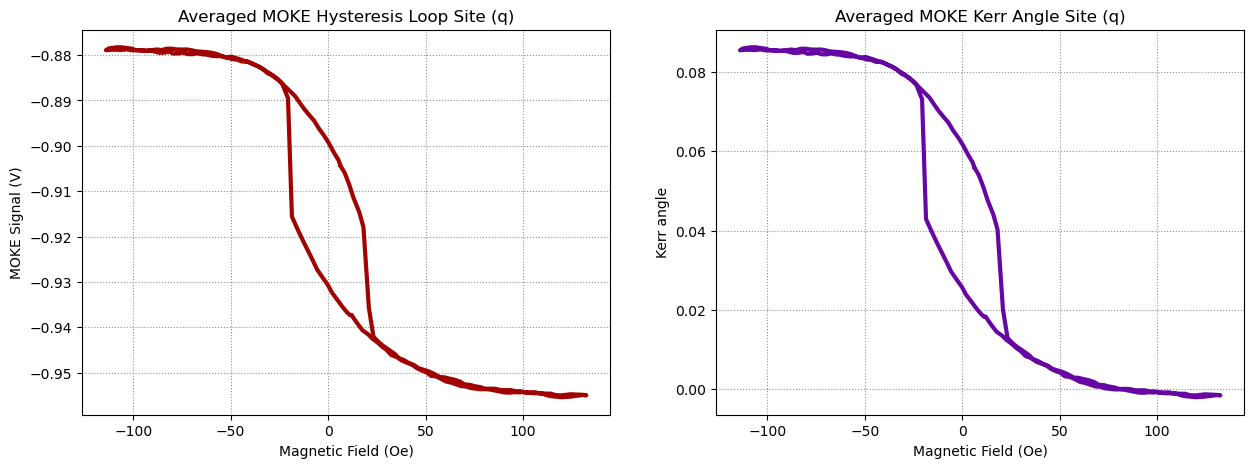

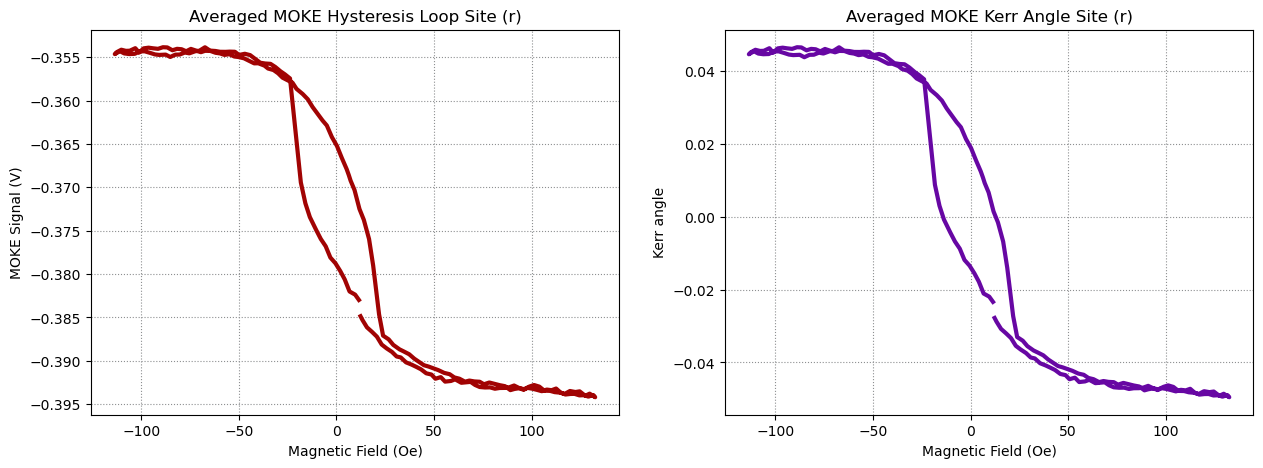

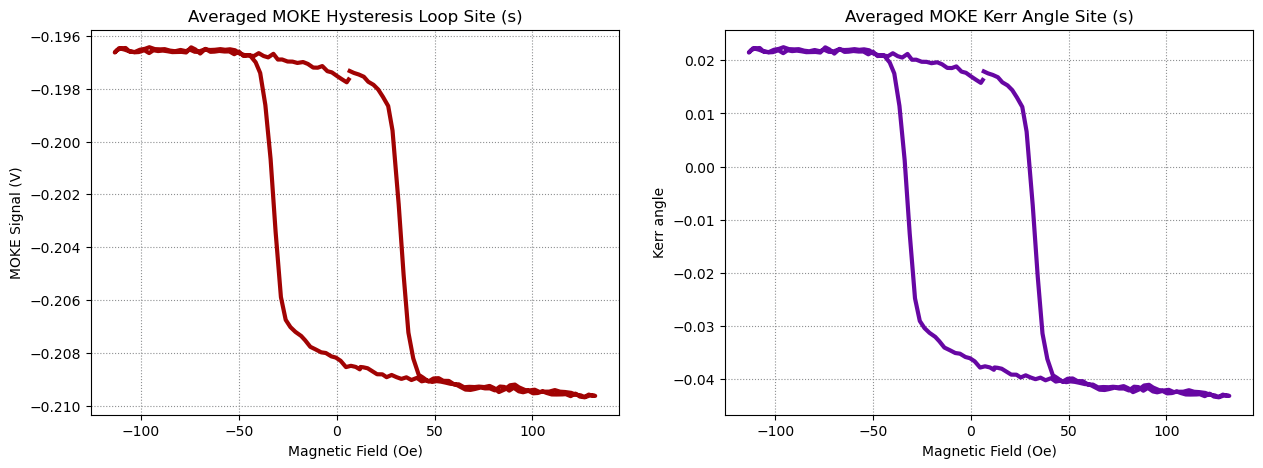

In [99]:
'''
author: amir kamalian
date: 28 may 2026

second series of MOKE scans
'''

import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

# headers: time(ms),field(Oe),signal(V),angle,step
# j = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G5.csv') --> did not scan
# k = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G1.csv') --> did not scan

l = pd.read_csv('../../MOKE-raw-data/2026_MAY_27-GdCo_Lily_LELM_P8.csv')
m = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P7.csv')
n = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P6.csv')
o = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P5.csv')
p = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_R1LM_P4.csv')
q = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_R1LM_P3.csv')
r = pd.read_csv('../../MOKE-raw-data/2026_MAY_25-GdCo_Lily_R1LM_P2.csv')
s = pd.read_csv('../../MOKE-raw-data/2026_MAY_25-GdCo_Lily_LERC_P1.csv')

df = [l, m, n, o, p, q, r, s]
titles = ["(l)", "(m)", "(n)", "(o)", "(p)", "(q)", "(r)", "(s)"]
n = 0

''' 
we must take the average of each of the polarities
'''
for G in df:
    # separating the cycles by steps 
    G["cycle"] = (G["step"].diff() < 0).cumsum()
    
    # separating polarities 
    even_polarity = G[G["cycle"] % 2 == 0]
    odd_polarity = G[G["cycle"] % 2 == 1]
    
    # averaging the respective polarities 
    evenp_avg = even_polarity.groupby("step").aggregate({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })
    
    oddp_avg = odd_polarity.groupby("step").aggregate({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })
    
    
    # combining results
    df_final = pd.concat([evenp_avg, oddp_avg], axis=0)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios" : [1,1]})
    
    # ax1: applied field vs signal 
    ax1.plot(df_final["field(Oe)"], df_final["signal(V)"], color="#a10303", linewidth=3)
    
    ax1.set_xlabel("Magnetic Field (Oe)")
    ax1.set_ylabel("MOKE Signal (V)")
    ax1.set_title("Averaged MOKE Hysteresis Loop Site " + titles[n])
    ax1.grid(which="minor", color="#8d8f91", linestyle=":")
    ax1.grid(which="major", color="#8d8f91", linestyle=":")
    
    # ax2: applied field vs kerr angle 
    ax2.plot(df_final["field(Oe)"], -df_final["angle"], color="#6707a3", linewidth=3)
    
    ax2.set_xlabel("Magnetic Field (Oe)")
    ax2.set_ylabel("Kerr angle")
    ax2.set_title("Averaged MOKE Kerr Angle Site " + titles[n])
    ax2.grid(which="minor", color="#8d8f91", linestyle=":")
    ax2.grid(which="major", color="#8d8f91", linestyle=":")
    # plt.savefig("./GdCo_Lily_second_series_plots/2026_MAY_28-GdCo_LL3S_kerrRotation_averagedCurves_scan_site_" + titles[n])

    n+=1

plt.show()




---
<h1>Normalized Hysteresis Curves</h1>

Reference amplitude = 0.052595125000000006
(l) Amplitude = 0.052595125000000006  Relative = 1.0
(m) Amplitude = 0.066207125  Relative = 1.2588072563759474
(n) Amplitude = 0.0673684  Relative = 1.2808867742019814
(o) Amplitude = 0.0730763  Relative = 1.3894120415152542
(p) Amplitude = 0.072676  Relative = 1.3818010699660852
(q) Amplitude = 0.0882425  Relative = 1.6777695651450584
(r) Amplitude = 0.09614629999999999  Relative = 1.8280458502570338
(s) Amplitude = 0.0659386  Relative = 1.253701745171249


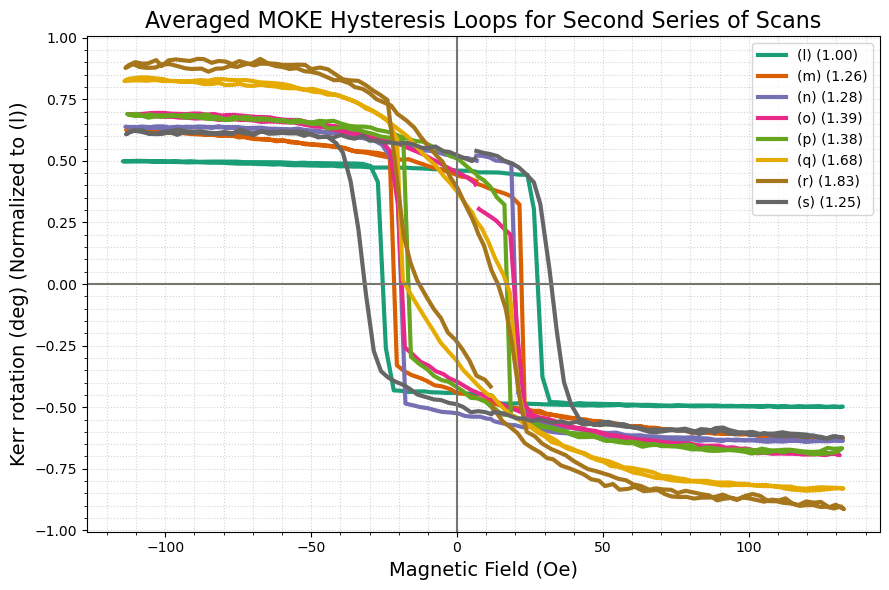

In [102]:
'''
author: amir kamalia 
date:   28 may 2026
'''

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# headers: time(ms),field(Oe),signal(V),angle,step
# j = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G5.csv') --> did not scan
# k = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G1.csv') --> did not scan

l = pd.read_csv('../../MOKE-raw-data/2026_MAY_27-GdCo_Lily_LELM_P8.csv') # --> lowest composition of Co
m = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P7.csv')
n = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P6.csv')
o = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P5.csv')
p = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_R1LM_P4.csv')
q = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_R1LM_P3.csv')
r = pd.read_csv('../../MOKE-raw-data/2026_MAY_25-GdCo_Lily_R1LM_P2.csv')
s = pd.read_csv('../../MOKE-raw-data/2026_MAY_25-GdCo_Lily_LERC_P1.csv') # --> "highest" composition of Co

dfs = [l, m, n, o, p, q, r, s]
titles = ["(l)", "(m)", "(n)", "(o)", "(p)", "(q)", "(r)", "(s)"]
n = 0


# FUNCTION: AVERAGE HYSTERESIS LOOP
def process_loop(G):

    # Detect cycles
    G = G.copy()

    G["cycle"] = (G["step"].diff() < 0).cumsum()

    # Separate sweep directions
    even_polarity = G[G["cycle"] % 2 == 0]
    odd_polarity  = G[G["cycle"] % 2 == 1]

    # Average each polarity
    even_avg = even_polarity.groupby("step").agg({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean" 
    })

    odd_avg = odd_polarity.groupby("step").agg({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })

    # Combine branches
    field = pd.concat([
        even_avg["field(Oe)"],
        odd_avg["field(Oe)"]
    ])

    signal = pd.concat([
        even_avg["signal(V)"],
        odd_avg["signal(V)"]
    ])

    angle = pd.concat([
        even_avg["angle"],
        odd_avg["angle"]
    ])

    # Remove vertical offset
    offset = (angle.max() + angle.min()) / 2

    angle_centered = angle - offset

    # Compute amplitude
    amplitude = (angle_centered.max() - angle_centered.min())

    return field, angle_centered, amplitude

# =========================================================
# REFERENCE NORMALIZATION
# =========================================================

# Using (l) dataset as the reference
ref_field, ref_angle, reference_amplitude = process_loop(l)

print("Reference amplitude =", reference_amplitude)

# =========================================================
# PLOTTING ALL LOOPS TOGETHER
# =========================================================

fig, ax = plt.subplots(figsize=(9,6))
colors = plt.cm.Dark2(np.linspace(0, 1, len(dfs)))

for n, G in enumerate(dfs):

    # Process loop
    field, angle_centered, amplitude = process_loop(G)

    # Normalize to REFERENCE amplitude
    angle_scaled = angle_centered / reference_amplitude
    
    # Print amplitudes
    relative_amplitude = amplitude / reference_amplitude

    print(titles[n], "Amplitude =", amplitude, " Relative =", relative_amplitude)

    # Plot
    ax.plot(field, -angle_scaled, color=colors[n], linewidth=3, label=f"{titles[n]} ({relative_amplitude:.2f})")

# =========================================================
# FORMAT PLOT
# =========================================================

ax.set_xlabel("Magnetic Field (Oe)", fontsize=14)
ax.set_ylabel("Kerr rotation (deg) (Normalized to (l))", fontsize=14)
ax.set_title("Averaged MOKE Hysteresis Loops for Second Series of Scans", fontsize=16)
ax.minorticks_on()
ax.grid(which="minor", color="#d0d5db", linestyle=":")
ax.grid(which="major", color="#d0d5db", linestyle=":")
ax.legend()
ax.axhline(color="#787671")
ax.axvline(color="#787671")

plt.tight_layout()
# plt.savefig("./GdCo_Lily_second_series_plots/2026_MAY_28-GdCo_LL3S_kerrRotation_normalized_second_series")

plt.show()




---
<h1>Hysteresis Amplitudes</h1>

0.019008250000000004
0.010148999999999991
0.013368900000000003
0.01493609999999998
0.024031499999999983
0.03295080000000006
0.04034070000000001
0.011299799999999999
  sample  amplitude
0    (l)   0.019008
1    (m)   0.010149
2    (n)   0.013369
3    (o)   0.014936
4    (p)   0.024031
5    (q)   0.032951
6    (r)   0.040341
7    (s)   0.011300


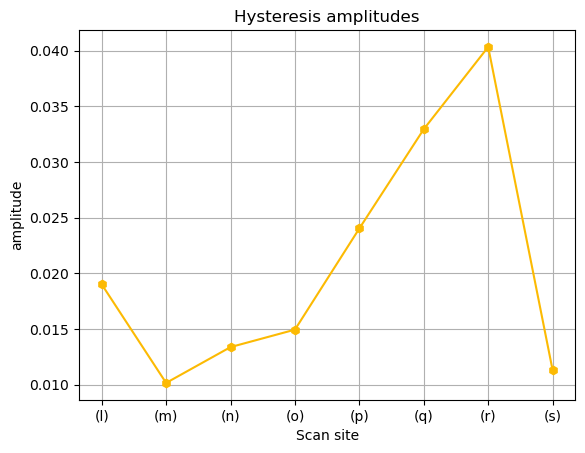

In [103]:
'''
author: amir kamalian
date:   28 may 2026

Hysteresis amplitudes 
'''

import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

# headers: time(ms),field(Oe),signal(V),angle,step
# j = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G5.csv') --> did not scan
# k = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G1.csv') --> did not scan

l = pd.read_csv('../../MOKE-raw-data/2026_MAY_27-GdCo_Lily_LELM_P8.csv') # --> lowest composition of Co
m = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P7.csv')
n = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P6.csv')
o = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P5.csv')
p = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_R1LM_P4.csv')
q = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_R1LM_P3.csv')
r = pd.read_csv('../../MOKE-raw-data/2026_MAY_25-GdCo_Lily_R1LM_P2.csv')
s = pd.read_csv('../../MOKE-raw-data/2026_MAY_25-GdCo_Lily_LERC_P1.csv') # --> "highest" composition of Co

dfs = [l, m, n, o, p, q, r, s]
titles = ["(l)", "(m)", "(n)", "(o)", "(p)", "(q)", "(r)", "(s)"]
n = 0

def average_out(dataframe: pd.DataFrame): 
    # separating the cycles by steps 
    dataframe["cycle"] = (dataframe["step"].diff() < 0).cumsum()
    
    # separating polarities 
    even_polarity = dataframe[dataframe["cycle"] % 2 == 0]
    odd_polarity = dataframe[dataframe["cycle"] % 2 == 1]
    
    # averaging the respective polarities 
    evenp_avg = even_polarity.groupby("step").aggregate({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })
    
    oddp_avg = odd_polarity.groupby("step").aggregate({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })

    # combining results
    amplitude = (evenp_avg["signal(V)"].max() - oddp_avg["signal(V)"].min()) 
    print(amplitude)

    return amplitude


# hysteresis amplitudes 
amplitudes = []
for d in df:
    amplitudes.append(average_out(d))

# convert to dataframe 
amp_df = pd.DataFrame({
    "sample": ["(l)", "(m)", "(n)", "(o)", "(p)", "(q)", "(r)", "(s)"],
    "amplitude": amplitudes
})

print(amp_df)

plt.plot(amp_df["sample"], amp_df["amplitude"], color="#fcba03", marker="h")
plt.grid()
plt.xlabel("Scan site")
plt.ylabel("amplitude")
plt.title("Hysteresis amplitudes")
# plt.savefig("./GdCo_Lily_second_series_plots/2026_MAY_28-GdCo_LL3S_hysteresis_amplitudes_second_series")

plt.show()


---
<h1>Coercivity</h1>

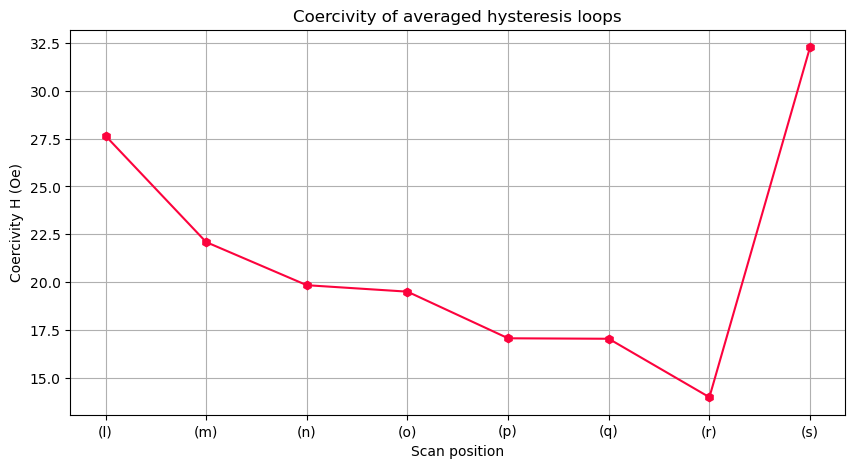

In [104]:
'''
author: amir kamalian
date: 28 may 2026

coercivity vs composition 
'''

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# headers: time(ms),field(Oe),signal(V),angle,step
# j = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G5.csv') --> did not scan
# k = pd.read_csv('../../MOKE-raw-data/2026_MAY_21-GdCo_Lily_NE1M_G1.csv') --> did not scan

l = pd.read_csv('../../MOKE-raw-data/2026_MAY_27-GdCo_Lily_LELM_P8.csv') # --> lowest composition of Co
m = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P7.csv')
n = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P6.csv')
o = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_L1LM_P5.csv')
p = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_R1LM_P4.csv')
q = pd.read_csv('../../MOKE-raw-data/2026_MAY_26-GdCo_Lily_R1LM_P3.csv')
r = pd.read_csv('../../MOKE-raw-data/2026_MAY_25-GdCo_Lily_R1LM_P2.csv')
s = pd.read_csv('../../MOKE-raw-data/2026_MAY_25-GdCo_Lily_LERC_P1.csv') # --> "highest" composition of Co

dfs = [l, m, n, o, p, q, r, s]
titles = ["(l)", "(m)", "(n)", "(o)", "(p)", "(q)", "(r)", "(s)"]
n = 0

# ---------------------------------------------------------------------------------
# FUNCTION: AVERAGE HYSTERESIS LOOP
def process_loop(G):

    # Detect cycles
    G = G.copy()

    G["cycle"] = (G["step"].diff() < 0).cumsum()

    # Separate sweep directions
    even_polarity = G[G["cycle"] % 2 == 0]
    odd_polarity  = G[G["cycle"] % 2 == 1]

    # Average each polarity
    even_avg = even_polarity.groupby("step").agg({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean" 
    })

    odd_avg = odd_polarity.groupby("step").agg({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })

    # Combine branches
    field = pd.concat([
        even_avg["field(Oe)"],
        odd_avg["field(Oe)"]
    ])

    signal = pd.concat([
        even_avg["signal(V)"],
        odd_avg["signal(V)"]
    ])

    angle = pd.concat([
        even_avg["angle"],
        odd_avg["angle"]
    ])

    # Remove vertical offsets
    angle_offset = (angle.max() + angle.min()) / 2
    signal_offset = (signal.max() + signal.min()) / 2

    angle_centered = angle - angle_offset
    signal_centered = signal - signal_offset

    df_final = pd.concat([field, signal_centered, angle_centered], axis=1)

    return df_final
    

# FUNCTION: determning the zero crossings (for coercivity plot)
def zero_crossing(df: pd.DataFrame, ylabel: str):

    field = np.array(df['field(Oe)'])
    ylabel = np.array(df[ylabel])
    
    zero_crossings = []
    for i in range(len(ylabel) - 1):
        y1 = ylabel[i]
        y2 = ylabel[i + 1]

        # zero crossing has been detected
        if y1*y2 < 0:
            H1 = field[i]
            H2 = field[i + 1]

            # Linear interpolation
            Hc = H1 - y1 * (H2 - H1) / (y2 - y1)

            zero_crossings.append(Hc)

    return zero_crossings
# ---------------------------------------------------------------------------------


# plotting coercivity versus scanned positions 
p_coercivity = []
n_coercivity = []
n=0
for n, G in enumerate(dfs):
    
    data = process_loop(G) 
    zeros = zero_crossing(data, 'angle')

    if zeros[0] > 0:
        p_coercivity.append(zeros[0])
    elif zeros[0] < 0:
        n_coercivity.append(zeros[0])
    
    if zeros[1] > 0:
        p_coercivity.append(zeros[1])
    elif zeros[1] < 0:
        n_coercivity.append(zeros[1])


# converting to dataframe
coerc_df = pd.DataFrame({
    "sample" : ["(l)", "(m)", "(n)", "(o)", "(p)", "(q)", "(r)", "(s)"],
    "coercivity(Oe)" : p_coercivity
})

# plotting positive coercivity values only 
plt.figure(figsize=(10,5))
plt.plot(coerc_df['sample'], coerc_df['coercivity(Oe)'], color="#fc033d", marker="h")
plt.title("Coercivity of averaged hysteresis loops")
plt.ylabel("Coercivity H (Oe)")
plt.xlabel("Scan position")
plt.grid()

# plt.savefig("./GdCo_Lily_second_series_plots/2026_MAY_28-GdCo_LL3S_coercivity_second_series")

plt.show()
    



